Crop Yield and Production Analysis

Problem Statement :

Agricultural productivity is affected by various factors such as crop type, season, area, and production levels. Analyzing agricultural datasets helps identify trends, missing values, and important patterns that can support better farming decisions and improve crop yield prediction.



- Which crops have the highest production?
- Which seasons produce better crop yields?
- Is there a relationship between cultivation area and production?
- Which columns contain missing values and how can they be handled?
- Which crops provide maximum yield with minimum area?

- How does production vary across seasons and crop types?

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Observation

This project performs data cleaning, missing value handling, grouping, pivot tables, and outlier detection on agricultural crop production data using Python libraries like Pandas and Seaborn.
The analysis helps identify crop production trends, seasonal patterns, and area-wise insights for better agricultural decision-making

df=pd.read_csv(r'C:\Users\mohan\OneDrive\Pictures\Desktop\crop  project\data\crop recomendation.csv')
df

In [4]:
 #Load the dataset
df = pd.read_csv(r'C:\Users\mohan\OneDrive\Pictures\Desktop\crop  project\data\crop recomendation.csv')

In [3]:
df.head()

,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,NaN,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,NaN


In [5]:
df.shape


(345336, 8)

- The shape of a data is 345336 rows, 8 coloumns of the data set


Categorical Data Types:
- State
- District
- Crop
- Season

Numerical Data Types:
- Area
- Production
- Yield

Discrete Data Types:
- Crop_Year

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  object 
 1   District    345336 non-null  object 
 2   Crop        334720 non-null  object 
 3   Crop_Year   345336 non-null  int64  
 4   Season      328922 non-null  object 
 5   Area        325254 non-null  float64
 6   Production  333543 non-null  float64
 7   Yield       329204 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 21.1+ MB




Observation


* `df.info()` Displays complete information about the dataset.
* It shows the number of rows, columns, column names, data types, and missing/null values present in the dataset.


Checking the null values 

In [5]:
df.isnull().sum()

State             0
District          0
Crop          10616
Crop_Year         0
Season        16414
Area          20082
Production    11793
Yield         16132
dtype: int64

Observation

Checking the null values:
- Null values are checking data
- Are  the null values and the total of the sum of the data
- The null values are 
- Crop , Season,Area,Production,Yield


In [6]:
round(df.isnull().sum()/len(df)*100)

State         0.0
District      0.0
Crop          3.0
Crop_Year     0.0
Season        5.0
Area          6.0
Production    3.0
Yield         5.0
dtype: float64

Observation

Missing Value Percentage
Crop → 3% missing values
Season → 5% missing values
Area → 6% missing values
Production → 3% missing values
Yield → 5% missing values

In [8]:
df["Crop"]=df["Crop"].fillna(df["Crop"].mode()[0])

In [9]:
df["Season"]=df["Season"].fillna(df["Season"].mode()[0])

In [10]:
df["Yield"]=df["Yield"].fillna(df["Yield"].mean())

In [11]:
 #Strip hidden spaces from all column names
df.columns = df.columns.str.strip()

# Now your original code will work perfectly!
df["Area"] =df["Area"].fillna(df["Area"].median())

In [12]:
df["Production"]=df["Production"].fillna(df["Production"].median())

In [13]:
df.drop(columns=['Yield'], inplace=True)

In [14]:
# Rename 'Crop_Year' to 'Year' (or whatever new name you prefer)
df = df.rename(columns={"Crop_Year": "Year"})

In [15]:
#Rename " Area" to area
df=df.rename(columns={"Area":"area"})

In [16]:
# Check duplicate rows in the dataset
df.duplicated().sum()

np.int64(9)

In [17]:
df = df.drop_duplicates()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345327 entries, 0 to 345335
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345327 non-null  object 
 1   District    345327 non-null  object 
 2   Crop        345327 non-null  object 
 3   Year        345327 non-null  int64  
 4   Season      345327 non-null  object 
 5   area        345327 non-null  float64
 6   Production  345327 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 21.1+ MB


Observation

- Crop,Season,Yield is to be filled  into the data to the null values.
- The values represent the average production for each crop in the dataset.

In [19]:
df.groupby(["Crop"])["area"].mean()

Crop
Arecanut                  3868.799408
Arhar/Tur                 7225.159047
Bajra                    22653.969254
Banana                    1673.984941
Barley                    2467.970595
Black pepper              3031.254140
Cardamom                  2186.332512
Cashewnut                 4567.888038
Castor seed               3960.370804
Coconut                  12308.844098
Coriander                 1593.107055
Cotton(lint)             34305.641307
Cowpea(Lobia)              697.906290
Dry chillies              1391.897165
Garlic                     705.901364
Ginger                     415.440799
Gram                     15882.438607
Groundnut                10011.299824
Guar seed                30907.153470
Horse-gram                2148.588056
Jowar                    17327.221369
Jute                      8850.531031
Khesari                   5387.329625
Linseed                   1299.909535
Maize                     8390.278100
Masoor                    3959.892026
Mesta  

Observation

- I will be grouped the data is taken crop and area
- In the crop in which the  area to select
-Analysis
- Cotton (lint) has the highest average production (34,305.64), indicating it is one of the most productive crops in the dataset.
- Bajra has the second-highest average production (22,653.97).
- Coconut also shows high production (12,308.84).
- Cowpea (Lobia) has the lowest average production (697.91).
- Crops such as Banana, Coriander, and Dry Chillies have relatively lower average production compared to major crops like Cotton and Bajra.

In [20]:
df.groupby(["area"])["Production"].mean()

area
0.004              717.0
0.008              717.0
0.010                1.0
0.024              717.0
0.040              359.0
                 ...    
3989200.000    2899500.0
4205800.000    3183800.0
5251200.000    3519600.0
5544000.000    4485800.0
8580100.000    7556300.0
Name: Production, Length: 45930, dtype: float64

Observation


The analysis examines the relationship between cultivated area and production. By grouping records based on area and calculating the mean production, we can observe how production changes with variations in cultivated land area. Generally, larger cultivated areas tend to produce higher agricultural output, indicating a positive relationship between area and production

In [21]:
df.groupby(["Season"])["Year"].mean()

Season
Autumn         2009.522805
Kharif         2008.804180
Rabi           2009.385809
Summer         2010.075001
Whole Year     2007.810539
Winter         2009.600000
Name: Year, dtype: float64

Observation :

The dataset was grouped by season, and the average crop year was calculated for each season. This analysis helps identify the time distribution of agricultural activities across different seasons. It provides insights into whether certain seasons are more prominent in recent years compared to others.

In [22]:
df.groupby(["Crop"])["Year"].mean()

Crop
Arecanut                 2008.653052
Arhar/Tur                2008.648764
Bajra                    2008.531732
Banana                   2008.978861
Barley                   2008.192807
Black pepper             2010.452941
Cardamom                 2008.810376
Cashewnut                2009.944589
Castor seed              2008.376325
Coconut                  2008.999295
Coriander                2009.370424
Cotton(lint)             2008.775887
Cowpea(Lobia)            2015.055262
Dry chillies             2008.617921
Garlic                   2009.345183
Ginger                   2009.135448
Gram                     2008.469551
Groundnut                2008.818889
Guar seed                2010.688661
Horse-gram               2009.203015
Jowar                    2008.204122
Jute                     2008.390178
Khesari                  2009.263466
Linseed                  2007.866923
Maize                    2009.023911
Masoor                   2009.631008
Mesta                    2008.711

In [23]:
df.groupby(["District"])["Crop"].agg(lambda x: x.mode()[0])

District
ADILABAD                    Rice
AGAR MALWA     Moong(Green Gram)
AGRA                       Maize
AHMADABAD                   Rice
AHMEDNAGAR                 Maize
                     ...        
YADAGIRI                    Rice
YAMUNANAGAR                 Rice
YANAM                       Rice
YAVATMAL               Groundnut
ZUNHEBOTO                   Rice
Name: Crop, Length: 707, dtype: object

Observation
This groups the dataset by District and finds the most frequently cultivated crop (mode) in each district.

groupby("District") → Groups records district-wise.
["Crop"] → Selects the Crop column.
mode()[0] → Returns the crop that appears most often in that district.
agg() → Applies the custom aggregation function.

In [24]:
df.groupby(["Season"])["Crop"].agg(lambda x: x.mode()[0])

Season
Autumn              Rice
Kharif              Rice
Rabi               Wheat
Summer              Rice
Whole Year     Sugarcane
Winter              Rice
Name: Crop, dtype: object

In [25]:
df.groupby(["District","Crop","Season"])["Production"].mean()


District   Crop            Season     
ADILABAD   Arhar/Tur       Kharif         19698.260870
                           Rabi             723.357143
           Bajra           Kharif           375.500000
                           Rabi             630.375000
           Banana          Kharif           775.200000
                                              ...     
ZUNHEBOTO  Urad            Kharif            28.000000
                           Rabi              42.727273
           Wheat           Kharif           468.500000
                           Rabi             722.888889
           other oilseeds  Kharif           130.750000
Name: Production, Length: 37905, dtype: float64

In [26]:
df.groupby(["District","Crop","Season"])["Year"].mean()

District   Crop            Season     
ADILABAD   Arhar/Tur       Kharif         2008.086957
                           Rabi           2007.785714
           Bajra           Kharif         2015.000000
                           Rabi           2006.750000
           Banana          Kharif         2016.600000
                                             ...     
ZUNHEBOTO  Urad            Kharif         2012.200000
                           Rabi           2012.636364
           Wheat           Kharif         2012.500000
                           Rabi           2009.166667
           other oilseeds  Kharif         2017.250000
Name: Year, Length: 37905, dtype: float64

In [27]:
df.groupby(["District","Crop","Season"])["Production"].mean()

District   Crop            Season     
ADILABAD   Arhar/Tur       Kharif         19698.260870
                           Rabi             723.357143
           Bajra           Kharif           375.500000
                           Rabi             630.375000
           Banana          Kharif           775.200000
                                              ...     
ZUNHEBOTO  Urad            Kharif            28.000000
                           Rabi              42.727273
           Wheat           Kharif           468.500000
                           Rabi             722.888889
           other oilseeds  Kharif           130.750000
Name: Production, Length: 37905, dtype: float64

observation

This groups the dataset by District, Crop, and Season, and calculates the average production for each combination.

District → Agricultural region.
Crop → Type of crop grown.
Season → Growing season (Kharif, Rabi, etc.).
Production → Crop production quantity.
mean() → Calculates average production.

In [28]:
pd.crosstab(df["Year"],df["Crop"])

Crop,Arecanut,Arhar/Tur,Bajra,Banana,Barley,Black pepper,Cardamom,Cashewnut,Castor seed,Coconut,...,Soyabean,Sugarcane,Sunflower,Sweet potato,Tapioca,Tobacco,Turmeric,Urad,Wheat,other oilseeds
Year,,,,,,,,,,,,,,,,,,,,,
1997,73,400,256,43,223,21,7,14,64,56,...,115,312,171,68,46,58,91,326,389,0
1998,77,414,295,125,250,33,25,33,154,81,...,197,434,344,131,75,152,189,436,436,6
1999,61,403,318,146,204,35,22,40,233,83,...,192,468,360,221,95,162,237,523,399,0
2000,88,446,354,173,254,33,21,58,239,107,...,185,452,295,188,85,167,248,467,438,14
2001,83,442,343,122,251,29,12,35,192,104,...,179,443,342,209,55,180,248,496,434,9
2002,74,374,350,188,251,31,18,67,213,132,...,180,454,340,243,96,200,257,502,448,41
2003,107,469,358,218,257,38,27,65,212,128,...,181,449,382,247,93,181,248,564,455,96
2004,62,374,343,170,249,39,28,61,241,113,...,196,418,381,327,61,183,257,490,477,22
2005,110,369,332,197,240,43,27,62,195,135,...,199,466,313,287,91,181,205,493,463,20


In 2019, there were 574 records for Arhar/Tur, 473 records for Bajra, and 510 records for Wheat.
In 1997, there were 400 records for Arhar/Tur and 389 records for Wheat.
The year 2020 contains very low counts because it appears to have incomplete data.

In [29]:
pd.crosstab(index=df["Year"], columns=df["Crop"], values=df["Production"], aggfunc="sum")

Crop,Arecanut,Arhar/Tur,Bajra,Banana,Barley,Black pepper,Cardamom,Cashewnut,Castor seed,Coconut,...,Soyabean,Sugarcane,Sunflower,Sweet potato,Tapioca,Tobacco,Turmeric,Urad,Wheat,other oilseeds
Year,,,,,,,,,,,,,,,,,,,,,
1997,246378.0,1656900.0,7211921.0,1608966.0,1527420.0,55398.0,1220.0,74142.0,776657.0,5.583968e+09,...,5191876.0,192758971.0,231524.0,231849.0,2875100.0,396536.0,56528.0,768608.0,59105461.0,NaN
1998,697527.0,2616061.0,5953950.0,6186763.0,1509986.0,74097.0,10012.0,81566.0,837820.0,6.120190e+09,...,6515069.0,258678623.0,759405.0,272467.0,5526385.0,581509.0,187521.0,1145862.0,67655571.0,7731.0
1999,145669.0,2507851.0,5748734.0,5750329.0,1248985.0,65914.0,10679.0,103559.0,718364.0,6.623545e+09,...,6788328.0,276821933.0,540145.0,535413.0,6004739.0,498278.0,292882.0,1384468.0,73444511.0,NaN
2000,355151.0,2207374.0,6602770.0,6323228.0,1392060.0,79262.0,12501.0,141449.0,877429.0,9.087232e+09,...,4798537.0,278170140.0,494406.0,444023.0,6151750.0,651401.0,285556.0,1229673.0,67314071.0,1153.0
2001,323030.0,2211266.0,7829755.0,4002634.0,1362077.0,80536.0,12669.0,127931.0,585165.0,8.096979e+09,...,5798508.0,273685764.0,627499.0,450375.0,2648312.0,729256.0,152991.0,1265016.0,67051157.0,843.0
2002,193696.0,1541819.0,4435791.0,6166651.0,1350314.0,91473.0,13355.0,153329.0,430643.0,1.170316e+10,...,4544706.0,279612336.0,782433.0,516156.0,4385244.0,776848.0,560257.0,1248728.0,61613014.0,18110.0
2003,424658.0,2155172.0,11692512.0,10808175.0,1275242.0,89385.0,13952.0,170638.0,789997.0,1.109427e+10,...,7405607.0,227336671.0,847971.0,573436.0,5917696.0,842569.0,194117.0,1393858.0,67638775.0,283907.0
2004,337519.0,1823851.0,7341040.0,7329925.0,1124168.0,103300.0,14966.0,165147.0,785398.0,1.317006e+10,...,6539223.0,226062447.0,1225347.0,884402.0,6567829.0,867805.0,238232.0,923913.0,67520580.0,1027.0
2005,1274210.0,2145547.0,6802875.0,9415376.0,1119315.0,122307.0,14932.0,180162.0,944924.0,1.334698e+10,...,7553844.0,284196922.0,1258100.0,499088.0,7312247.0,911406.0,239405.0,922824.0,64017083.0,851.0


Observation:
 Coconut shows the highest production across most years, reaching billions in production.
Sugarcane consistently records very high production values compared to other crops.
Wheat production increases gradually over the years.
Banana production shows significant growth after 2010.
Bajra production fluctuates across years.
The year 2020 contains many missing (NaN) or very low values, indicating incomplete data.

In [30]:

pd.crosstab(df["Season"],df['District'])

District,ADILABAD,AGAR MALWA,AGRA,AHMADABAD,AHMEDNAGAR,AIZAWL,AJMER,AKOLA,ALAPPUZHA,ALIGARH,...,WEST SIANG,WEST SINGHBHUM,WEST TRIPURA,WOKHA,YADADRI,YADAGIRI,YAMUNANAGAR,YANAM,YAVATMAL,ZUNHEBOTO
Season,,,,,,,,,,,,,,,,,,,,,
Autumn,0,0,0,0,1,10,0,0,22,0,...,0,38,4,0,0,0,0,1,0,0
Kharif,363,69,309,301,390,177,334,278,32,295,...,127,74,223,415,69,205,202,37,275,380
Rabi,373,34,198,90,219,74,168,136,0,211,...,39,110,157,201,43,117,127,59,132,175
Summer,0,7,72,66,64,0,0,39,21,93,...,0,4,4,0,0,65,0,19,40,0
Whole Year,83,51,29,80,23,48,163,20,229,35,...,116,10,31,13,0,42,110,32,22,13
Winter,0,0,0,0,0,0,0,0,22,0,...,0,19,4,0,0,0,0,2,0,0


observation:
Kharif season has the highest number of crop records in most districts.
Rabi season is the second most common cultivation season.
Whole Year crops are also cultivated in many districts.
Summer, Autumn, and Winter have comparatively fewer records.
Some districts, such as ADILABAD and AHMEDNAGAR, show agricultural activity across multiple seasons.

In [31]:
#pivot table:
pd.pivot_table(df,index=["Season"],columns=["District"],values=["Production"],aggfunc="sum")

Production                                                  \
District       ADILABAD AGAR MALWA        AGRA   AHMADABAD   AHMEDNAGAR   
Season                                                                    
Autumn              NaN        NaN         NaN         NaN       1113.0   
Kharif       16151509.0  1276265.0   6915748.0  12878987.0   19121134.0   
Rabi          2486507.0  1818549.0  34293312.0   5525037.0   10806192.0   
Summer              NaN     1533.0     19169.0    666721.0     260368.0   
Whole Year     532651.0  1080131.0   4304522.0   1143329.0  141157351.0   
Winter              NaN        NaN         NaN         NaN          NaN   

                                                                        ...  \
District       AIZAWL      AJMER       AKOLA     ALAPPUZHA     ALIGARH  ...   
Season                                                                  ...   
Autumn        41003.0        NaN         NaN  4.300260e+05         NaN  ...   
Kharif       464672.0  5344971.0  13553059.0  7.467200e+04  17759549.0  ...   
Rabi          22655.0  5138628.0   2145186.0           NaN  26633605.0  ...   
Summer            NaN        NaN     70173.0  9.431790e+05     66257.0  ...   
Whole Year   251341.0   274498.0    542378.0  5.983775e+09   4474360.0  ...   
Winter            NaN        NaN         NaN  5.493880e+05         NaN  ...   

                                                                          \
District    WEST SIANG WEST SINGHBHUM WEST TRIPURA      WOKHA    YADADRI   
Season                                                                     
Autumn             NaN       111041.0       8853.0        NaN        NaN   
Kharif        655165.0      1151443.0    3871739.0  1630640.0  1259449.0   
Rabi           10695.0       103266.0      34106.0   213997.0   777040.0   
Summer             NaN          461.0     114291.0        NaN        NaN   
Whole Year    187666.0        10111.0     231164.0    95427.0        NaN   
Winter             NaN      1494694.0     202303.0        NaN        NaN   

                                                                        
District       YADAGIRI YAMUNANAGAR       YANAM    YAVATMAL  ZUNHEBOTO  
Season                                                                  
Autumn              NaN         NaN      1184.0         NaN        NaN  
Kharif        5718944.0   6047797.0   2600177.0  21556942.0  1350349.0  
Rabi           598699.0   6412272.0     17371.0   1654391.0   118017.0  
Summer         677771.0         NaN       370.0    213356.0        NaN  
Whole Year   12257818.0  44639408.0  69955266.0   9763311.0    99360.0  
Winter              NaN         NaN      2476.0         NaN        NaN  

[6 rows x 707 columns]

Observation:
- Kharif season contributes the highest production in many districts.

Rabi season also shows significant agricultural production.

Whole Year crops generate extremely high production in some districts such as ALAPPUZHA and AHMEDNAGAR.

Summer and Winter seasons generally contribute less production compared to Kharif and Rabi.

Production varies greatly across districts, indicating differences in agricultural practices and crop suitability.
-

Outlier Capping using Quantile Method

In [32]:
lower_limit=df["area"].quantile(0.05)
upper_limit=df["area"].quantile(0.95)
print(lower_limit)
print(upper_limit)
# cap the outliers:
df["area_cap"]=df["area"].clip(lower=lower_limit,upper=upper_limit)
print(df)
len(df)

4.0
62101.40000000002
                             State  District      Crop  Year       Season  \
0       Andaman and Nicobar Island  NICOBARS  Arecanut  2007  Kharif        
1       Andaman and Nicobar Island  NICOBARS  Arecanut  2007  Rabi          
2       Andaman and Nicobar Island  NICOBARS  Arecanut  2008  Autumn        
3       Andaman and Nicobar Island  NICOBARS  Arecanut  2008  Summer        
4       Andaman and Nicobar Island  NICOBARS  Arecanut  2009  Autumn        
...                            ...       ...       ...   ...          ...   
345331                 West Bengal   PURULIA     Wheat  2015  Rabi          
345332                 West Bengal   PURULIA      Rice  2016  Rabi          
345333                 West Bengal   PURULIA     Wheat  2017  Rabi          
345334                 West Bengal   PURULIA     Wheat  2018  Kharif        
345335                 West Bengal   PURULIA     Wheat  2019  Rabi          

          area  Production  area_cap  
0       2439.6

345327

Outlier treatment was performed on the Area column using the capping method. The 5th percentile (4.0) and 95th percentile (62101.4) were used as lower and upper limits. Values outside these limits were replaced with the respective threshold values. This process reduced the impact of extreme observations and improved the reliability of subsequent analysis and visualizations

In [33]:
Q1=df["area_cap"].quantile(0.25)
Q3=df["area_cap"].quantile(0.75)
IQR=Q3-Q1
outliers = df[(df['area_cap'] < (Q1 - 1.5 * IQR)) | (df['area_cap'] > (Q3 + 1.5 * IQR))]
print(outliers)
len(outliers)

                             State  District      Crop  Year       Season  \
207     Andaman and Nicobar Island  NICOBARS  Coconut   2007  Whole Year    
208     Andaman and Nicobar Island  NICOBARS  Coconut   2008  Whole Year    
209     Andaman and Nicobar Island  NICOBARS  Coconut   2009  Whole Year    
210     Andaman and Nicobar Island  NICOBARS  Coconut   2000  Whole Year    
211     Andaman and Nicobar Island  NICOBARS  Coconut   2001  Whole Year    
...                            ...       ...       ...   ...          ...   
345279                 West Bengal     NADIA     Wheat  2011  Rabi          
345280                 West Bengal     NADIA     Wheat  2012  Rabi          
345281                 West Bengal     NADIA     Wheat  2013  Rabi          
345282                 West Bengal     NADIA     Wheat  2014  Kharif        
345283                 West Bengal     NADIA     Wheat  2015  Rabi          

           area  Production  area_cap  
207     21636.0  80640000.0   21636

58207

Outlier detection was performed on the capped Area variable using the Interquartile Range (IQR) method. The first quartile (Q1) and third quartile (Q3) were calculated, and observations lying outside the range of Q1 − 1.5×IQR and Q3 + 1.5×IQR were identified as outliers. This analysis helped evaluate whether extreme values still existed after applying percentile-based capping.

In [34]:
Q1=df["area"].quantile(0.1)
Q3=df["area"].quantile(0.8)
IQR=Q3-Q1
outliers = df[(df['area'] < (Q1 - 1.5 * IQR)) | (df['area'] > (Q3 + 1.5 * IQR))]
print(outliers)
len(outliers)

                             State  District      Crop  Year       Season  \
207     Andaman and Nicobar Island  NICOBARS  Coconut   2007  Whole Year    
208     Andaman and Nicobar Island  NICOBARS  Coconut   2008  Whole Year    
209     Andaman and Nicobar Island  NICOBARS  Coconut   2009  Whole Year    
210     Andaman and Nicobar Island  NICOBARS  Coconut   2000  Whole Year    
211     Andaman and Nicobar Island  NICOBARS  Coconut   2001  Whole Year    
...                            ...       ...       ...   ...          ...   
345279                 West Bengal     NADIA     Wheat  2011  Rabi          
345280                 West Bengal     NADIA     Wheat  2012  Rabi          
345281                 West Bengal     NADIA     Wheat  2013  Rabi          
345282                 West Bengal     NADIA     Wheat  2014  Kharif        
345283                 West Bengal     NADIA     Wheat  2015  Rabi          

           area  Production  area_cap  
207     21636.0  80640000.0   21636

44411

In [35]:
#use capping method:
df["area_cap"]=df["area_cap"].clip(lower=lower_limit,upper=upper_limit)
print(df)
len(df)

                             State  District      Crop  Year       Season  \
0       Andaman and Nicobar Island  NICOBARS  Arecanut  2007  Kharif        
1       Andaman and Nicobar Island  NICOBARS  Arecanut  2007  Rabi          
2       Andaman and Nicobar Island  NICOBARS  Arecanut  2008  Autumn        
3       Andaman and Nicobar Island  NICOBARS  Arecanut  2008  Summer        
4       Andaman and Nicobar Island  NICOBARS  Arecanut  2009  Autumn        
...                            ...       ...       ...   ...          ...   
345331                 West Bengal   PURULIA     Wheat  2015  Rabi          
345332                 West Bengal   PURULIA      Rice  2016  Rabi          
345333                 West Bengal   PURULIA     Wheat  2017  Rabi          
345334                 West Bengal   PURULIA     Wheat  2018  Kharif        
345335                 West Bengal   PURULIA     Wheat  2019  Rabi          

          area  Production  area_cap  
0       2439.6      3415.0    2439.6

345327

In [36]:
 
df["Production"]=np.sqrt(df["Production"])

print(df)
len(df)

                             State  District      Crop  Year       Season  \
0       Andaman and Nicobar Island  NICOBARS  Arecanut  2007  Kharif        
1       Andaman and Nicobar Island  NICOBARS  Arecanut  2007  Rabi          
2       Andaman and Nicobar Island  NICOBARS  Arecanut  2008  Autumn        
3       Andaman and Nicobar Island  NICOBARS  Arecanut  2008  Summer        
4       Andaman and Nicobar Island  NICOBARS  Arecanut  2009  Autumn        
...                            ...       ...       ...   ...          ...   
345331                 West Bengal   PURULIA     Wheat  2015  Rabi          
345332                 West Bengal   PURULIA      Rice  2016  Rabi          
345333                 West Bengal   PURULIA     Wheat  2017  Rabi          
345334                 West Bengal   PURULIA     Wheat  2018  Kharif        
345335                 West Bengal   PURULIA     Wheat  2019  Rabi          

          area  Production  area_cap  
0       2439.6   58.438001    2439.6

345327

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345327 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345327 non-null  object 
 1   District    345327 non-null  object 
 2   Crop        345327 non-null  object 
 3   Year        345327 non-null  int64  
 4   Season      345327 non-null  object 
 5   area        345327 non-null  float64
 6   Production  345327 non-null  float64
 7   area_cap    345327 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 23.7+ MB


In [38]:
df.head()

,State,District,Crop,Year,Season,area,Production,area_cap
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,58.438001,2439.6
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,47.717921,1626.4
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,55.317267,4147.0
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,26.776856,4147.0
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,55.856960,4153.0


Univarient analysis:

perform univarient visual analysis of the data:

real_numerical --->hist,box,kde:

discr/categorical --->count plot,pie chart:


Text(0.5, 1.0, 'Area Distribution')

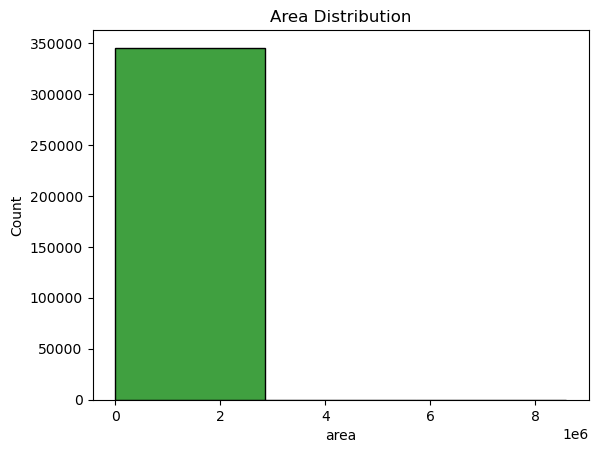

In [39]:
sns.histplot(df,x="area",bins=3,color="green")
plt.title("Area Distribution")

Observation:
- Most field at the  area is 0

Text(0, 0.5, 'Frequency')

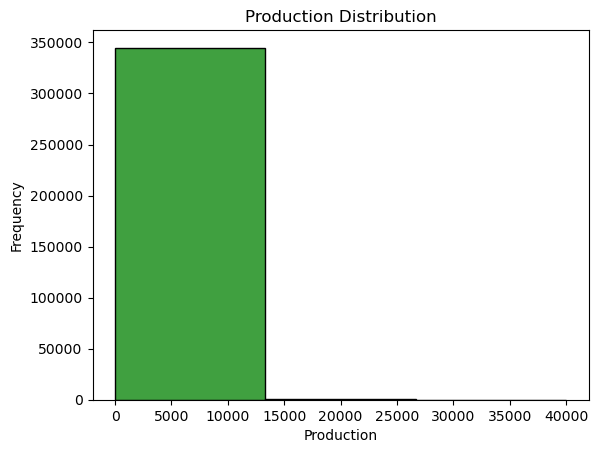

In [40]:

sns.histplot(df,x="Production",bins=3,color="green")
plt.title("Production Distribution")
plt.xlabel("Production")
plt.ylabel("Frequency")

observation:
This histogram visualizes the distribution of the Production variable in the dataset.

histplot() creates a histogram.
x="Production" selects the Production column.
bins=3 divides the production values into 3 intervals.
color="green" sets the bar color to green.

Text(0.5, 1.0, 'Outlier detection of area')

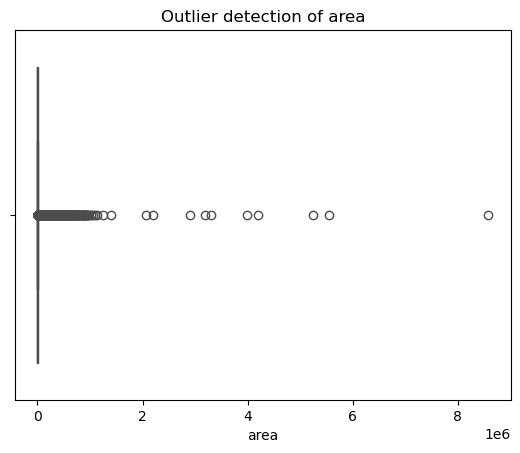

In [41]:
# boxplot:
sns.boxplot(df,x="area",color="grey")
plt.title("Outlier detection of area")

Observation:

The boxplot indicates the presence of several extreme values in the Area variable, confirming that cultivated area varies significantly across agricultural records.

Text(0.5, 1.0, 'Production Distribution')

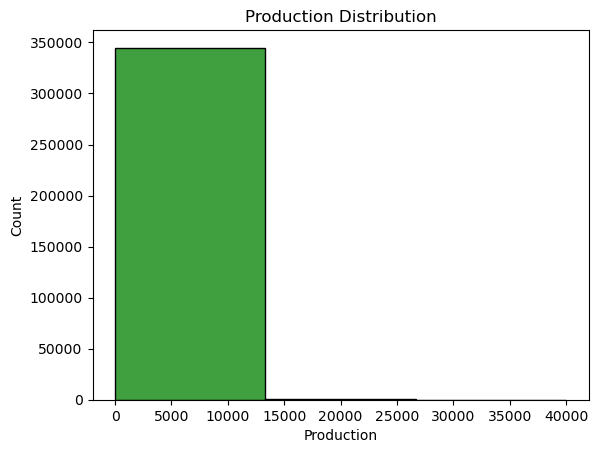

In [42]:
sns.histplot(df,x="Production",bins=3,color="green")
plt.title("Production Distribution")

- The production of a field is 1

Text(0.5, 1.0, 'KDE plot for Area.')

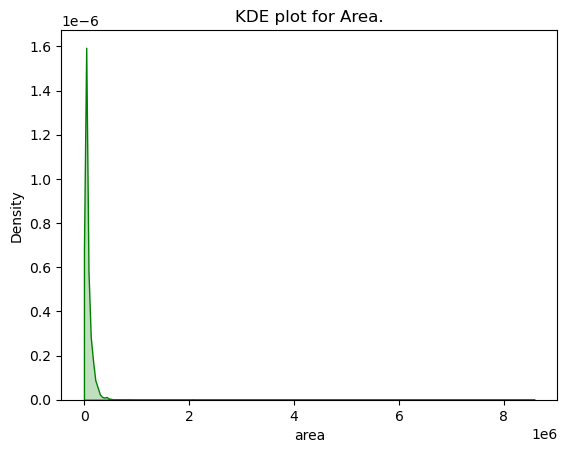

In [43]:
# KDE plot:
sns.kdeplot(df,
            x="area",
            fill=True,
            color="green")
plt.title("KDE plot for Area.")

observation:
In kde plot  the area as the density has 1.6

Text(0.5, 1.0, 'KDE plot for Production')

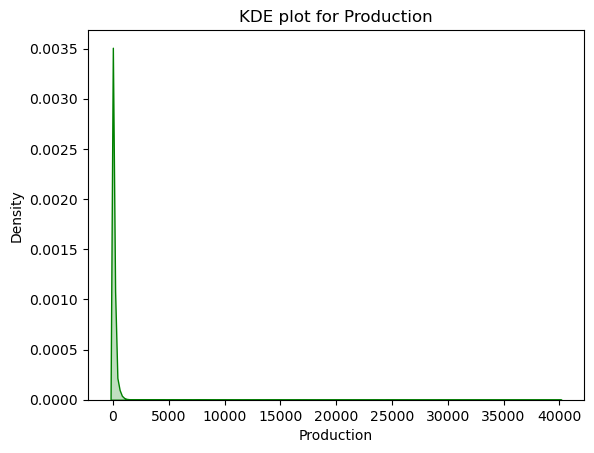

In [44]:

sns.kdeplot(df,x="Production",fill=True,
            color="green")
plt.title("KDE plot for Production")

obsevation ":
- In this production  as axis
- in this density as y axis
- In kde plot  the area as the density has 1.6

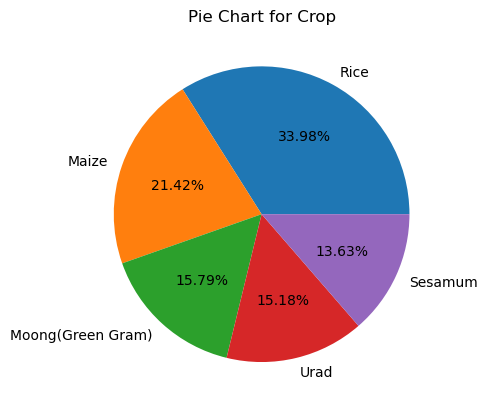

In [45]:
# Pie chart for Crop column

dependents = df["Crop"].value_counts().head(5)

plt.pie(dependents.values,
        labels=dependents.index,
        autopct="%0.2f%%")

plt.title("Pie Chart for Crop")
plt.show()

A pie chart was used to visualize the distribution of the top 5 crops in the dataset. The chart shows the percentage contribution of each crop, helping identify the most commonly cultivated crops. Larger slices represent crops with higher frequency, indicating their greater importance in agricultural activities.

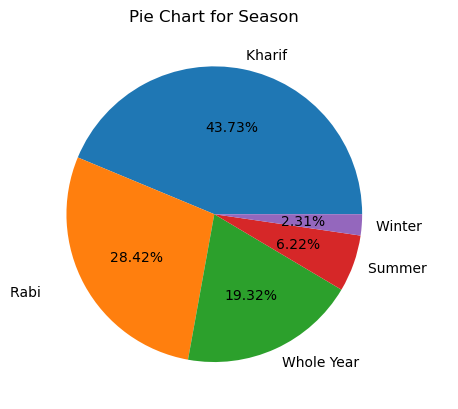

In [46]:
# Pie chart for Season column

dependents = df["Season"].value_counts().head(5)

plt.pie(dependents.values,
        labels=dependents.index,
        autopct="%0.2f%%")

plt.title("Pie Chart for Season")
plt.show()

pie chart was used to visualize the distribution of agricultural seasons in the dataset. The chart shows the percentage contribution of each season, helping identify the most dominant cropping seasons. Larger slices indicate seasons with higher agricultural activity and a greater number of crop records.

One-Line Explanation


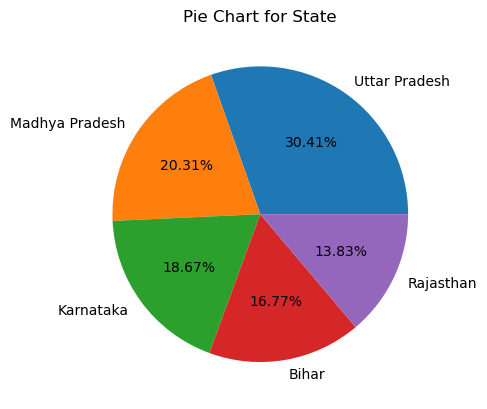

In [47]:
# Pie chart for State column

dependents = df["State"].value_counts().head(5)

plt.pie(dependents.values,
        labels=dependents.index,
        autopct="%0.2f%%")

plt.title("Pie Chart for State")
plt.show()

Crop Pie Chart

Observation:

The top five crops account for a substantial portion of the dataset. Rice appears as one of the most frequently cultivated crops.

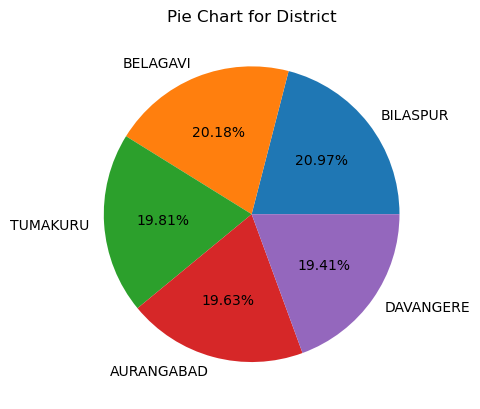

In [48]:
# Pie chart for District column

dependents = df["District"].value_counts().head(5)

plt.pie(dependents.values,
        labels=dependents.index,
        autopct="%0.2f%%")

plt.title("Pie Chart for District")
plt.show()

Observation:

The top five districts account for a substantial portion of the dataset. Rice appears as one of the most frequently cultivated districts.

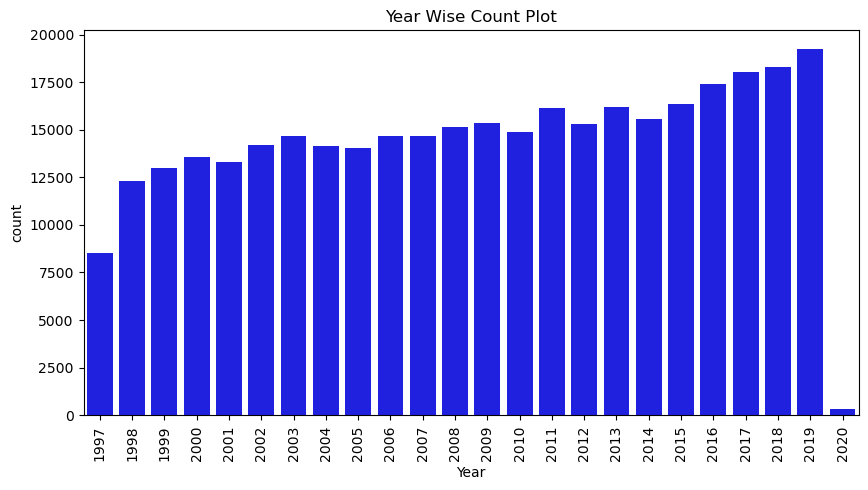

In [49]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Year", color="blue")

plt.title("Year Wise Count Plot")
plt.xticks(rotation=90)
plt.show()

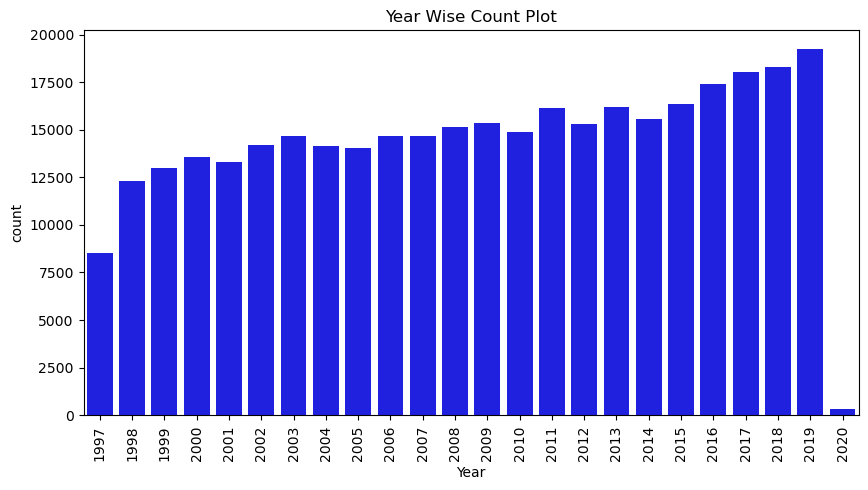

In [50]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Year", color="blue")

plt.title("Year Wise Count Plot")
plt.xticks(rotation=90)
plt.show()

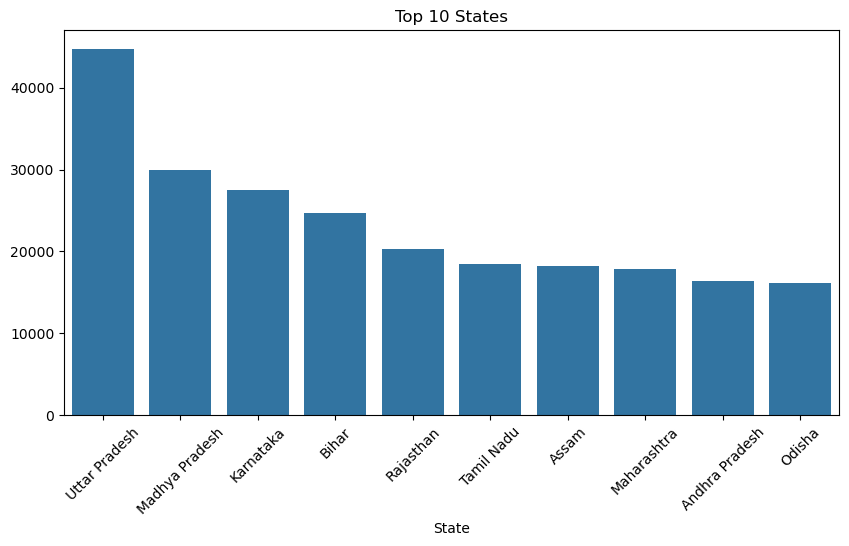

In [51]:
top_states = df["State"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_states.index,
            y=top_states.values)

plt.title("Top 10 States")
plt.xticks(rotation=45)
plt.show()

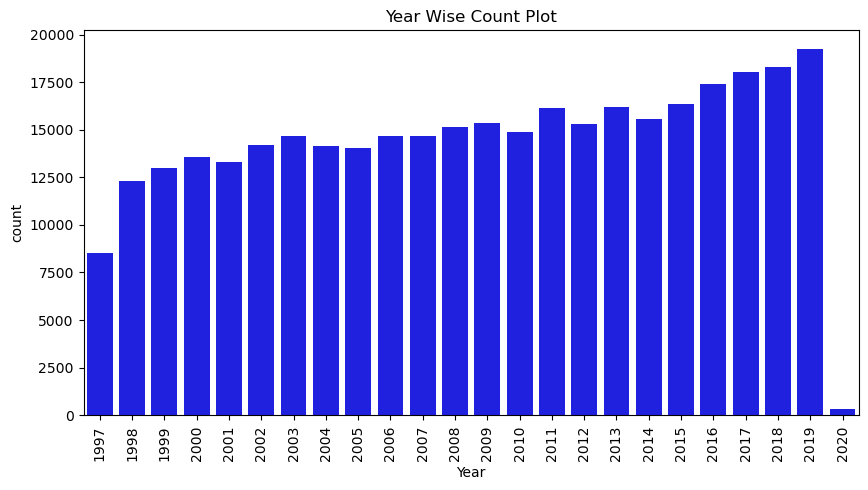

In [52]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Year", color="blue")

plt.title("Year Wise Count Plot")
plt.xticks(rotation=90)

plt.show()

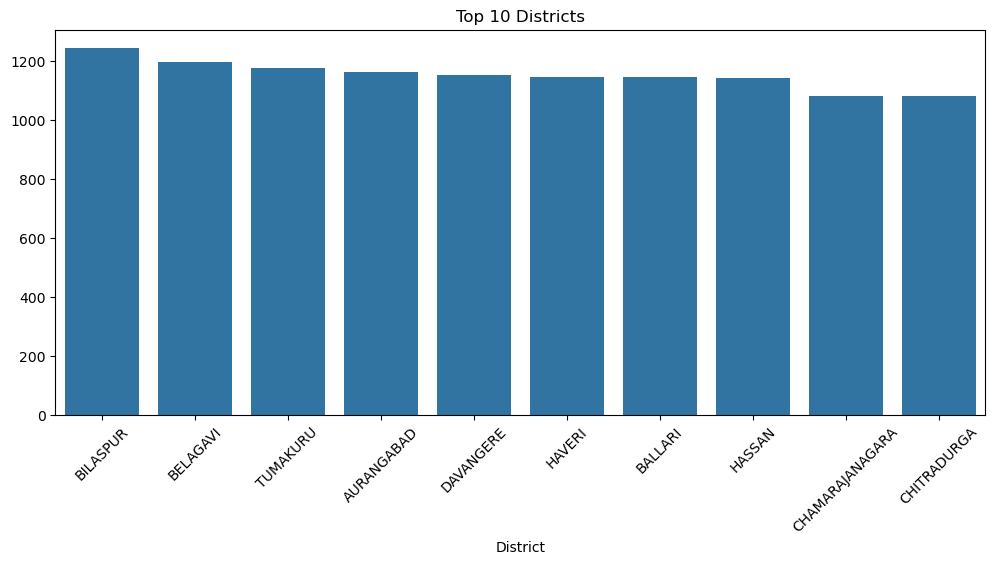

In [53]:
top_districts = df["District"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_districts.index,
            y=top_districts.values)

plt.title("Top 10 Districts")
plt.xticks(rotation=45)

plt.show()

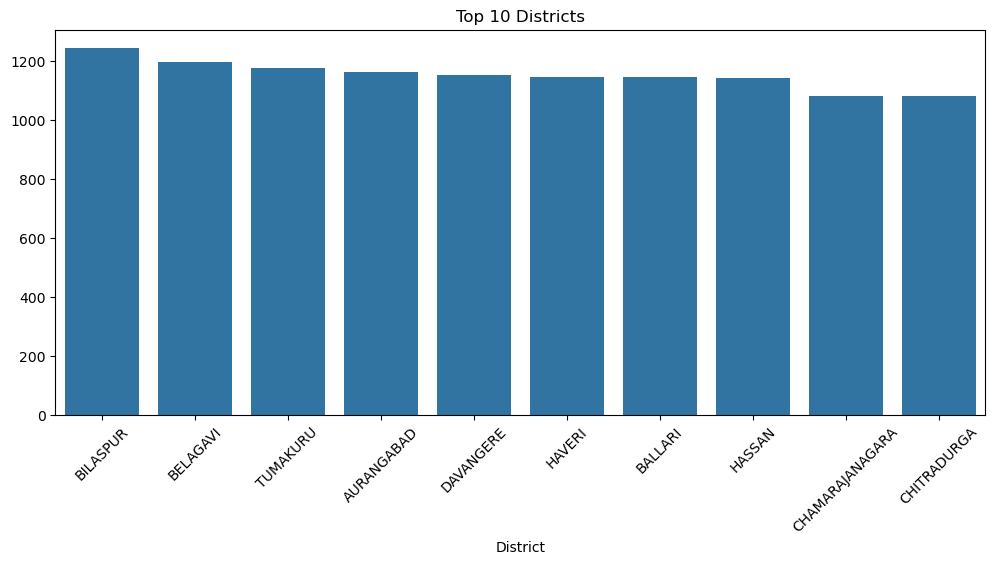

In [54]:
top_districts = df["District"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_districts.index,
            y=top_districts.values)

plt.title("Top 10 Districts")
plt.xticks(rotation=45)

plt.show()

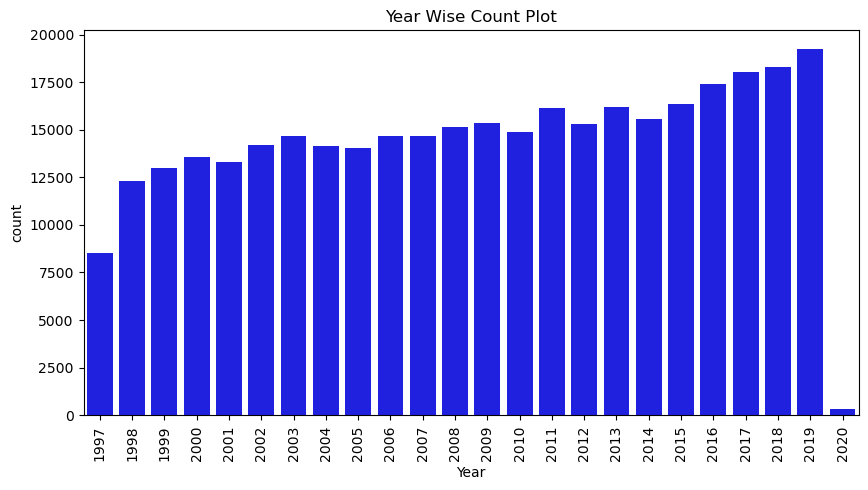

In [55]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Year", color="blue")

plt.title("Year Wise Count Plot")
plt.xticks(rotation=90)

plt.show()

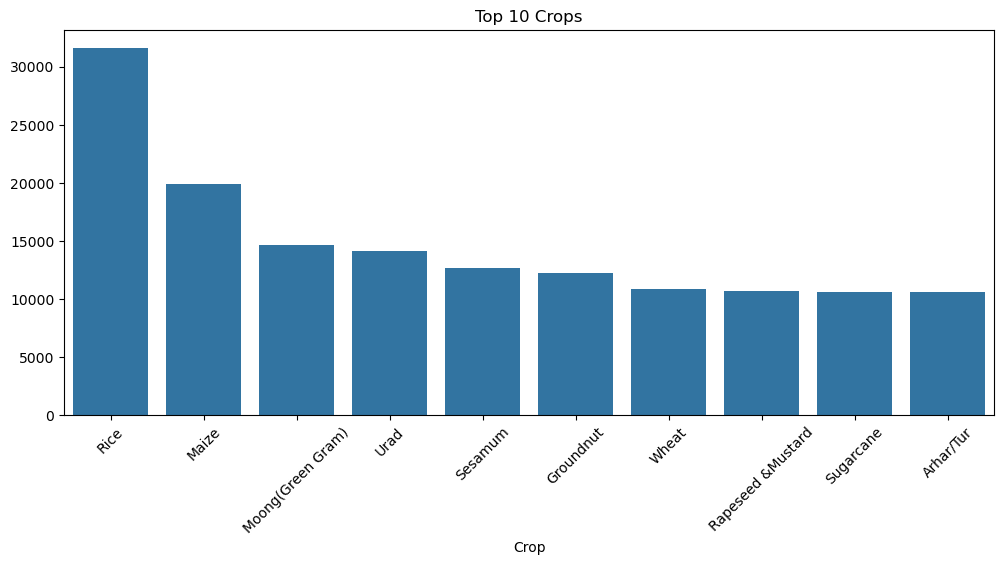

In [56]:
top_crops = df["Crop"].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(x=top_crops.index,
            y=top_crops.values)

plt.title("Top 10 Crops")
plt.xticks(rotation=45)

plt.show()

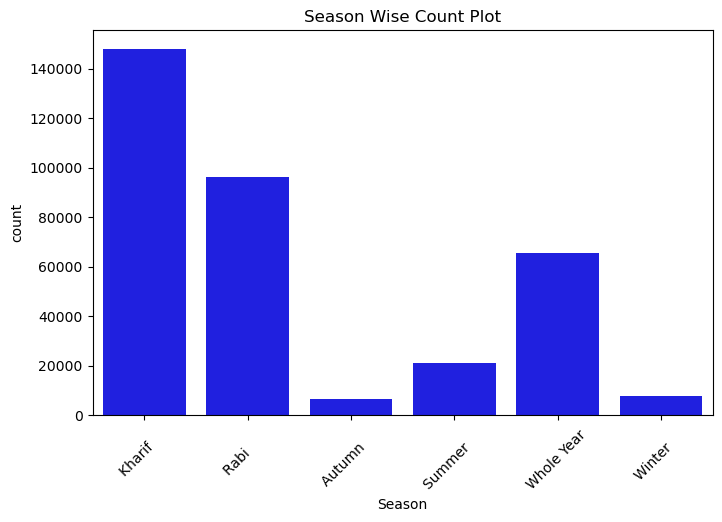

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Season", color="blue")

plt.title("Season Wise Count Plot")
plt.xticks(rotation=45)

plt.show()

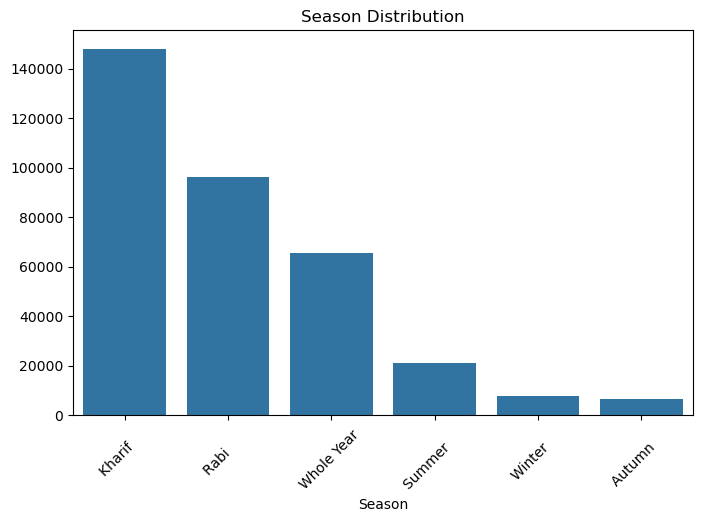

In [58]:
top_season = df["Season"].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=top_season.index,
            y=top_season.values)

plt.title("Season Distribution")
plt.xticks(rotation=45)

plt.show()

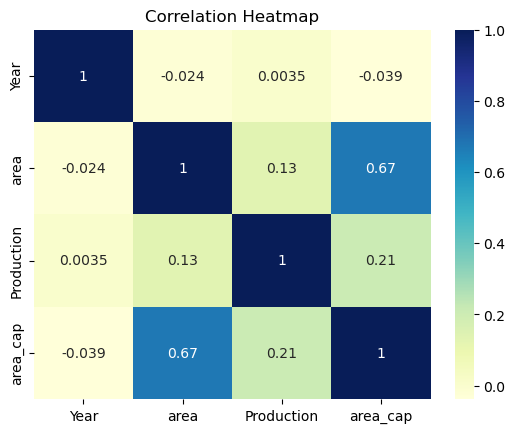

In [59]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="YlGnBu")

plt.title("Correlation Heatmap")
plt.show()

A correlation heatmap was created to examine the relationships among numerical variables in the crop dataset. The heatmap helps identify whether variables such as Area, Production, and Yield are positively or negatively related. Strong positive correlations indicate that an increase in one variable is associated with an increase in another variable, while negative correlations indicate an inverse relationship.

2. Top 10 Crops by Production

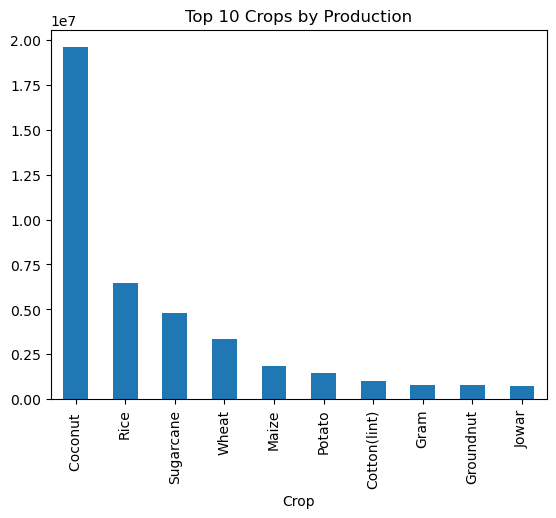

In [60]:
top_crop = df.groupby("Crop")["Production"].sum().sort_values(ascending=False).head(10)

top_crop.plot(kind="bar")
plt.title("Top 10 Crops by Production")
plt.show()

observation:
A bar chart was created to visualize the top 10 crops based on total production. The analysis helps identify the highest-producing crops in the dataset and compare their production levels. Crops with taller bars contribute more significantly to overall agricultural production.

season_wise by production

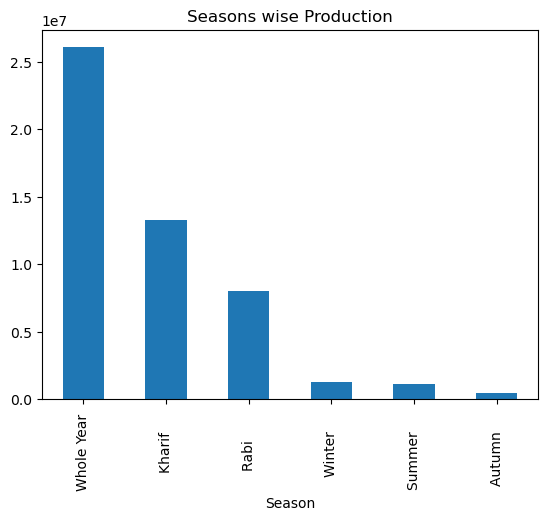

In [61]:
top_crop = df.groupby("Season")["Production"].sum().sort_values(ascending=False).head(10)

top_crop.plot(kind="bar")
plt.title("Seasons wise Production")
plt.show()

Observation:

Kharif season contributes the highest share of agricultural records, followed by Rabi and Whole Year seasons

"Top 10 States by Production"


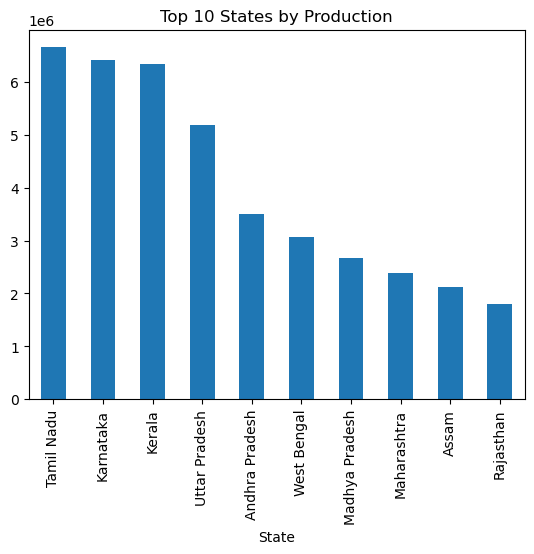

In [62]:
top_crop = df.groupby("State")["Production"].sum().sort_values(ascending=False).head(10)

top_crop.plot(kind="bar")
plt.title("Top 10 States by Production")
plt.show()

Observation:

A few states contribute a large proportion of agricultural records, indicating regional concentration of crop cultivation activities.

Top 10 Districts by Production

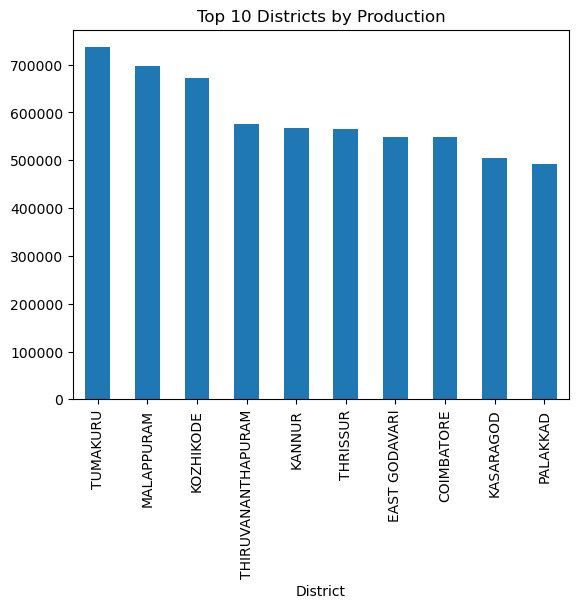

In [63]:
top_crop = df.groupby("District")["Production"].sum().sort_values(ascending=False).head(10)

top_crop.plot(kind="bar")
plt.title("Top 10 Districts by Production")
plt.show()

The top districts contribute a significant share of total observations, highlighting important agricultural regions.

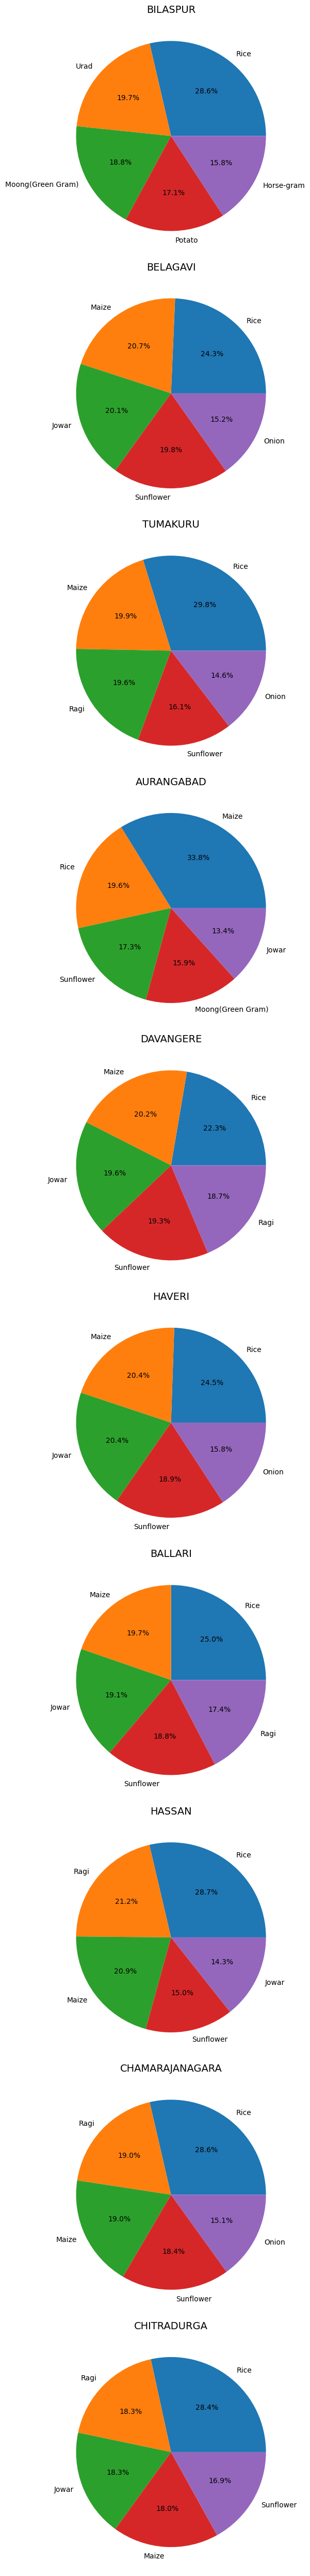

In [64]:


districts = df["District"].value_counts().head(10).index

fig, axes = plt.subplots(10, 1, figsize=(12, 50))

for ax, district in zip(axes, districts):

    crop_counts = df[df["District"] == district]["Crop"].value_counts().head(5)

    ax.pie(
        crop_counts.values,
        labels=crop_counts.index,
        autopct="%1.1f%%"
    )

    ax.set_title(district, fontsize=14)

plt.tight_layout()
plt.show()

Multiple pie charts were created to analyze the crop distribution across the top 10 districts. Each pie chart represents one district and displays the percentage share of the top 5 crops cultivated in that district. This visualization helps compare regional crop preferences and identify dominant crops in different districts.

In [65]:
# Top 10 Crops by Production
df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)
# Season-wise Production
df.groupby('Season')['Production'].sum().sort_values(ascending=False)

# State-wise Production
df.groupby('State')['Production'].sum().sort_values(ascending=False).head(10)



# Correlation
df[['area','Production']].corr()




,area,Production
area,1.00000,0.13373
Production,0.13373,1.00000


Probability Distribution Analysis on Crop Data

For our Crop Yield and Production Analysis project, you should not use Bernoulli, Binomial, and Poisson distributions with random data. Instead, relate them to your crop dataset.

Crop Distribution (Categorical Probability):

In [66]:
crop_prob = df["Crop"].value_counts(normalize=True)

print(crop_prob)

Crop
Rice                     0.091444
Maize                    0.057647
Moong(Green Gram)        0.042508
Urad                     0.040860
Sesamum                  0.036672
Groundnut                0.035352
Wheat                    0.031538
Rapeseed &Mustard        0.030921
Sugarcane                0.030742
Arhar/Tur                0.030571
Potato                   0.030186
Onion                    0.029908
Gram                     0.029387
Jowar                    0.027536
Dry chillies             0.025208
Bajra                    0.022906
Peas & beans (Pulses)    0.020302
Sunflower                0.020247
Small millets            0.019634
Cotton(lint)             0.018206
Masoor                   0.017893
Linseed                  0.016581
Barley                   0.016506
Sweet potato             0.016135
Other Kharif pulses      0.016051
Ragi                     0.016051
Turmeric                 0.015687
Horse-gram               0.015177
Garlic                   0.014908
Coriander

Explanation:

This calculates the probability of occurrence of each crop in the dataset. It helps identify the most frequently cultivated crops and their distribution across agricultural records.

In [67]:
season_prob = df["Season"].value_counts(normalize=True)

print(season_prob)

Season
Kharif         0.428825
Rabi           0.278736
Whole Year     0.189435
Summer         0.060965
Winter         0.022674
Autumn         0.019364
Name: proportion, dtype: float64


In [68]:
state_prob = df["State"].value_counts(normalize=True)

print(state_prob.head(10))

State
Uttar Pradesh     0.129677
Madhya Pradesh    0.086602
Karnataka         0.079614
Bihar             0.071518
Rajasthan         0.058967
Tamil Nadu        0.053587
Assam             0.052663
Maharashtra       0.051893
Andhra Pradesh    0.047381
Odisha            0.046773
Name: proportion, dtype: float64


In [69]:
pd.crosstab(
    df["Crop"],
    df["Season"],
    normalize="columns"
)

Season,Autumn,Kharif,Rabi,Summer,Whole Year,Winter
Crop,,,,,,
Arecanut,0.000299,0.000952,0.003605,0.000047,0.025055,0.000000
Arhar/Tur,0.002393,0.063700,0.008415,0.001377,0.003516,0.004981
Bajra,0.000000,0.043570,0.004800,0.024937,0.007200,0.000000
Banana,0.001196,0.003079,0.000073,0.019475,0.047908,0.000766
Barley,0.000000,0.003930,0.052693,0.000000,0.000703,0.000000
Black pepper,0.000299,0.000466,0.000873,0.000047,0.018405,0.000000
Cardamom,0.000000,0.000263,0.000000,0.000000,0.007949,0.000000
Cashewnut,0.000000,0.001418,0.000530,0.000000,0.019460,0.000000
Castor seed,0.000000,0.027552,0.002982,0.000000,0.002461,0.000000


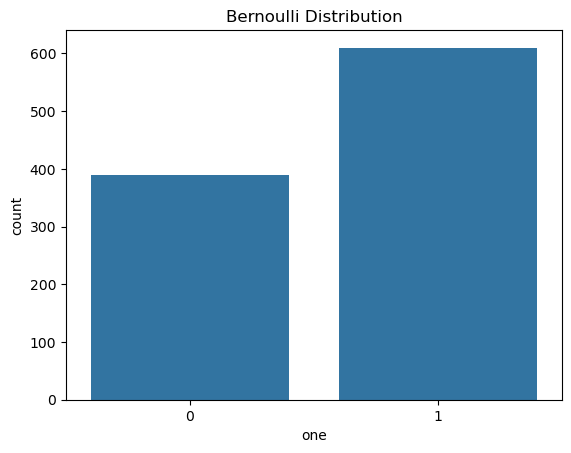

In [70]:
x = np.random.binomial(n=1, p=0.6, size=1000)

data = pd.DataFrame(x, columns=["one"])

sns.countplot(data=data, x="one")

plt.title("Bernoulli Distribution")
plt.show()

In [71]:
from scipy.stats import f_oneway

kharif = df[df["Season"]=="Kharif"]["Production"]
rabi = df[df["Season"]=="Rabi"]["Production"]
summer = df[df["Season"]=="Summer"]["Production"]

f_stat, p_value = f_oneway(kharif, rabi, summer)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: nan
P-Value: nan


C:\Users\mohan\AppData\Local\Temp\ipykernel_15636\1050343303.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(kharif, rabi, summer)


Observation
p-value < 0.05 → Significant difference exists.
p-value ≥ 0.05 → No significant difference exists.

Confidence Interval

In [72]:
import scipy.stats as stats

mean = df["Production"].mean()
sem = stats.sem(df["Production"])

ci = stats.t.interval(
    confidence=0.95,
    df=len(df)-1,
    loc=mean,
    scale=sem
)

print(ci)

(np.float64(142.22459261854888), np.float64(148.55142845980768))


Inferential statistics helps determine whether observed agricultural patterns are statistically significant and can be generalized beyond the sample data.

Bussiness anylist:
Conducted exploratory data analysis on agricultural crop production data using Python, Pandas, NumPy, Matplotlib, and Seaborn. Performed data cleaning, missing value treatment, outlier analysis, statistical analysis, crosstab and pivot table analysis, and data visualization to identify crop, seasonal, and district-level production trends. Generated actionable business insights to support agricultural planning and decision-making.


# Key Findings / Business Insights

1. Rice is the dominant crop across most districts and seasons, making it the backbone of agricultural production.

2. Kharif season contributes the highest cultivation activity, indicating the importance of monsoon-based farming.

3. Production is highly concentrated in a few crops such as Rice, Sugarcane, and Coconut.

4. Large variations exist between districts, suggesting the influence of climate and irrigation facilities.

5. Cultivated area and production show a positive relationship.

6. The dataset contains several outliers, indicating exceptionally productive regions.

7. Whole Year crops contribute substantially to total production.

8. Agricultural production is concentrated in a few states.

9. Rice has the highest occurrence probability among all crops.

10. Seasonal patterns strongly influence crop selection and production.

# Recommendations

1. Improve irrigation facilities in low-performing districts.
2. Promote high-yield crop varieties.
3. Encourage crop diversification.
4. Provide seasonal farming advisories.
5. Focus government support on low-productivity regions.
6. Invest in modern farming technologies.

Conclusion:
The Crop Yield and Production Analysis project successfully analyzed agricultural data to identify important patterns and trends. Data cleaning techniques such as missing value treatment, duplicate checking, and outlier handling improved data quality and reliability. Exploratory Data Analysis (EDA) revealed significant insights into crop production, seasonal variations, district-wise agricultural activities, and the relationship between cultivated area and production. Visualizations, crosstab analysis, and pivot tables helped understand agricultural performance across different regions and years. The findings can support farmers, agricultural organizations, and policymakers in making informed decisions, improving crop planning, and enhancing agricultural productivity.

Short Conclusion:
The analysis identified key crop, season, and district-level production trends. Data visualization and statistical analysis provided valuable insights that can help improve agricultural planning, resource allocation, and overall crop productivity.



* **Which crops have the highest production?**
  Crops such as Coconut, Sugarcane, Wheat, Cotton, and Rice contribute the highest production.

* **Which seasons produce better crop yields?**
  Kharif and Rabi seasons generally produce higher agricultural output than other seasons.

* **Is there a relationship between cultivation area and production?**
  Yes, production tends to increase as the cultivation area increases.

* **Which columns contain missing values and how can they be handled?**
  Crop, Season, Area, Production, and Yield contain missing values, which can be handled using mode and median imputation.

* **Which crops provide maximum yield with minimum area?**
  High-value crops such as Coconut, Banana, and Sugarcane often generate higher output from relatively smaller cultivation areas.

* **How does production vary across seasons and crop types?**
  Production varies significantly across crops and seasons, with Kharif and Rabi crops contributing the largest share of total production.
